# Imports

In [2]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold



In [50]:
def compute_deviation_from_baseline_to_intersection(curve, baseline, past=True):
    diff = curve - baseline
    idx_intersect = np.where(np.diff(np.sign(diff)))[0][0]
    print(idx_intersect)

    if past:
        deviation = compute_deviation_from_baseline(curve[idx_intersect:], baseline[idx_intersect:])
    else:
        deviation = compute_deviation_from_baseline(curve[:idx_intersect], baseline[:idx_intersect])
    return deviation

def compute_deviation_from_baseline(curve, baseline):
    deviation = np.abs(curve - baseline)
    return np.sum(deviation)

In [4]:
# results_path = "/home/me24/repos/earthquake-analysis/results/rrr/"
with open("lagged_results_all_areas.pkl", "rb") as f:
    res_ = pickle.load(f)

/tmp/ipykernel_1152679/3180258996.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis", len(keys))
/tmp/ipykernel_1152679/3180258996.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


Text(0.5, 1.0, 'MOp to left elbow. All trials. 300ms windows')

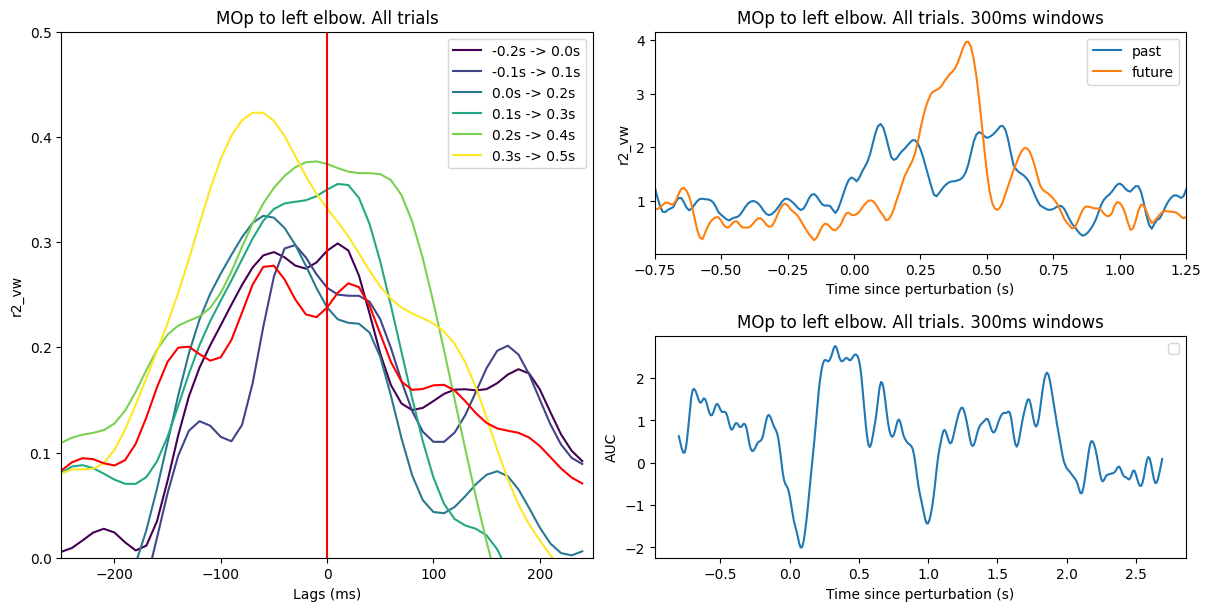

In [126]:
time_bins = np.arange(100, 450, step=1)
lags = np.arange(-25, 25, step=1)
window = 20
time_secs = (time_bins / 100) - 1.8
t_0_idx = np.where(lags == 0)[0][0]
score_type = 'r2_vw'


res = res_['MOp']

baseline_idx = np.where(np.array(list(res.keys())) < 200)[0]
baseline_mean = np.array([res[t][score_type].mean(-1) for t in np.array(list(res.keys()))[baseline_idx]]).mean(0)



fig = plt.figure(figsize=(12, 6), constrained_layout=True)
gs = mpl.gridspec.GridSpec(nrows=2, ncols=2, figure=fig, width_ratios=[1, 1.0], height_ratios=[1, 1])

ax_left = fig.add_subplot(gs[:, 0])   # spans both rows on the left
ax_rt   = fig.add_subplot(gs[0, 1])   # top-right
ax_rb   = fig.add_subplot(gs[1, 1])   # bottom-right

# keys = list(res.keys())[75:77] + list(res.keys())[100:102]
keys = np.arange(180, 240, step=10)
cmap = mpl.cm.get_cmap("viridis", len(keys))
colors = [cmap(i) for i in range(len(keys))]
# curves_masked = np.maximum(curves, 0)
for i, t in enumerate(keys):
    vizutils.shaded_errorbar(ax_left, lags*10, res[t][score_type], label=f'{np.round((t / 100) -2, 2)}s -> {np.round(((t+window) / 100) - 2, 2)}s', 
                            errorStat=scipy.stats.sem, alpha_err=0.0,
                            color=colors[i],
                            )
    

    # com_past = np.sum(lags[:t_0_idx] * res[t][score_type].mean(-1)[:t_0_idx]) / np.sum(res[t][score_type].mean(-1)[:t_0_idx])
    # com_future = np.sum(lags[t_0_idx:] * res[t][score_type].mean(-1)[t_0_idx:]) / np.sum(res[t][score_type].mean(-1)[t_0_idx:])

    # ax_left.axvline(com_past*10, color=colors[i])
    # ax_left.axvline(com_future*10, color=colors[i])
ax_left.plot(lags*10, baseline_mean, color='r')
ax_left.axvline(0, color='r')

ax_left.set_xlabel('Lags (ms)')
ax_left.set_title('MOp to left elbow. All trials')
ax_left.set_ylabel(f'{score_type}')
ax_left.legend()
ax_left.set_ylim(0, 0.5)
ax_left.set_xlim(-250, 250)



past, future = [], []
for t in res.keys():
    past_score, future_score = compute_past_future_score(lags, res[t][score_type].mean(-1), baseline_mean, t_0_idx)
    past.append(past_score)
    future.append(future_score)
    # past.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[:t_0_idx], baseline_mean[:t_0_idx]))
    # future.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[t_0_idx:], baseline_mean[t_0_idx:]))
    # past.append(compute_deviation_from_baseline_to_intersection(res[t][score_type].mean(-1)[:t_0_idx], baseline_mean[:t_0_idx], past=True))
    # future.append(compute_deviation_from_baseline_to_intersection(res[t][score_type].mean(-1)[t_0_idx:], baseline_mean[t_0_idx:], past=False))

ax_rt.errorbar(time_secs, past, fmt='-', label='past')
ax_rt.errorbar(time_secs, future, fmt='-', label='future')
ax_rt.set_ylabel(score_type)
ax_rt.set_xlabel('Time since perturbation (s)')
ax_rt.legend()
ax_rt.set_title("MOp to left elbow. All trials. 300ms windows")
ax_rt.set_xlim(-0.75, 1.25)
# ax_rt.set_ylim(0, 4.2)

auc_diff = []
for t in res.keys():
    auc_diff.append(diff_auc_left_auc_right(res[t][score_type].mean(-1), t_0_idx))

auc_diff = np.array(auc_diff)

ax_rb.plot(time_secs, auc_diff)
ax_rb.set_ylabel('AUC')
ax_rb.set_xlabel('Time since perturbation (s)')
ax_rb.legend()
ax_rb.set_title("MOp to left elbow. All trials. 300ms windows")


    

In [142]:
def diff_auc_left_auc_right(curve, t0_idx):
    auc_past = np.trapz(curve[:t0_idx])
    auc_future = np.trapz(curve[t0_idx:])
    return auc_past - auc_future

def compute_score(auc, deviation, com):
    w1 = 0
    w2 = 1
    w3 = 0
    return w1*auc + w2*deviation + w3*com

def compute_com(x, curve):
    return np.sum(x * curve) / np.sum(curve)

def compute_past_future_score(lags, curve, baseline, t0):
    auc_past = np.trapz(curve[:t0])
    auc_future = np.trapz(curve[t0:])

    deviation_past = np.sum(np.abs(curve[:t0] - baseline[:t0]))
    deviation_future = np.sum(np.abs(curve[t0:] - baseline[t0:]))

    com_past = np.sum(lags[:t0] * curve[:t0]) / np.sum(curve[:t0])
    com_future = np.sum(lags[t0:] * curve[t0:]) / np.sum(curve[t0:])

    past_score = compute_score(auc_past, deviation_past, com_past)
    future_score = compute_score(auc_future, deviation_future, com_future)
    return past_score, future_score

from scipy.optimize import curve_fit

def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2))



/tmp/ipykernel_1152679/3180575914.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis", len(keys))
/tmp/ipykernel_1152679/3180575914.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


Text(0.5, 1.0, 'MOp to left elbow. All trials. 300ms windows')

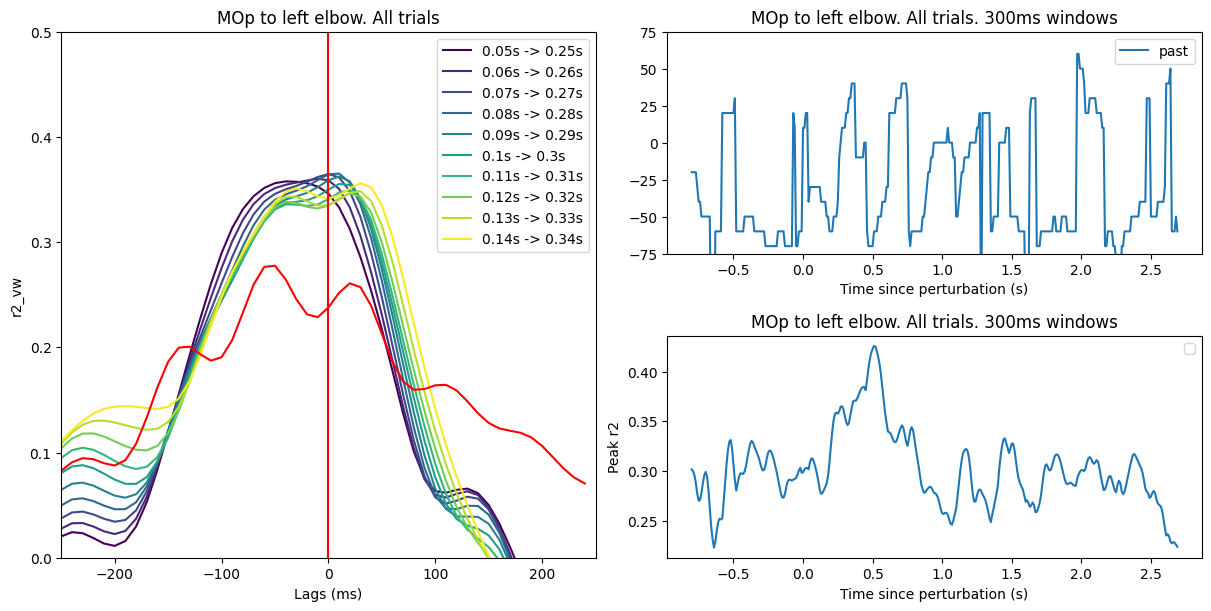

In [221]:
time_bins = np.arange(100, 450, step=1)
lags = np.arange(-25, 25, step=1)
window = 20
time_secs = (time_bins / 100) - 1.8
t_0_idx = np.where(lags == 0)[0][0]
score_type = 'r2_vw'


res = res_['MOp']

baseline_idx = np.where(np.array(list(res.keys())) < 200)[0]
baseline_mean = np.array([res[t][score_type].mean(-1) for t in np.array(list(res.keys()))[baseline_idx]]).mean(0)



fig = plt.figure(figsize=(12, 6), constrained_layout=True)
gs = mpl.gridspec.GridSpec(nrows=2, ncols=2, figure=fig, width_ratios=[1, 1.0], height_ratios=[1, 1])

ax_left = fig.add_subplot(gs[:, 0])   # spans both rows on the left
ax_rt   = fig.add_subplot(gs[0, 1])   # top-right
ax_rb   = fig.add_subplot(gs[1, 1])   # bottom-right

# keys = list(res.keys())[75:77] + list(res.keys())[100:102]
keys = np.arange(205, 215, step=1)
cmap = mpl.cm.get_cmap("viridis", len(keys))
colors = [cmap(i) for i in range(len(keys))]
# curves_masked = np.maximum(curves, 0)
for i, t in enumerate(keys):
    vizutils.shaded_errorbar(ax_left, lags*10, res[t][score_type], label=f'{np.round((t / 100) -2, 2)}s -> {np.round(((t+window) / 100) - 2, 2)}s', 
                            errorStat=scipy.stats.sem, alpha_err=0.0,
                            color=colors[i],
                            )
    mask = res[t][score_type].mean(-1) > baseline_mean
    com = compute_com(lags[mask], res[t][score_type].mean(-1)[mask])
    # print(com*10)
    # popt, _ = curve_fit(gaussian, lags, res[t][score_type].mean(-1), p0=[max(res[t][score_type].mean(-1)), 0, 50])
    # fitted_mean = popt[1]  # Extract mean parameter
    # com_past = np.sum(lags[:t_0_idx] * res[t][score_type].mean(-1)[:t_0_idx]) / np.sum(res[t][score_type].mean(-1)[:t_0_idx])
    # com_future = np.sum(lags[t_0_idx:] * res[t][score_type].mean(-1)[t_0_idx:]) / np.sum(res[t][score_type].mean(-1)[t_0_idx:])

    # ax_left.axvline(fitted_mean*10, color=colors[i])
    # ax_left.axvline(com*10, color=colors[i])
ax_left.plot(lags*10, baseline_mean, color='r')
ax_left.axvline(0, color='r')

ax_left.set_xlabel('Lags (ms)')
ax_left.set_title('MOp to left elbow. All trials')
ax_left.set_ylabel(f'{score_type}')
ax_left.legend()
ax_left.set_ylim(0, 0.5)
ax_left.set_xlim(-250, 250)



coms = []
diffs = []
peak_lags = []
means = []
for t in res.keys():
    mask = res[t][score_type].mean(-1) > baseline_mean
    coms.append(compute_com(lags[mask], res[t][score_type].mean(-1)[mask]))
    peak_lags.append(lags[np.argmax(res[t][score_type].mean(-1))] * 10)
    popt, _ = curve_fit(gaussian, lags, res[t][score_type].mean(-1), p0=[max(res[t][score_type].mean(-1)), 0, 50])
    means.append(popt[1] * 10)

ax_rt.plot(time_secs, peak_lags, label='past')
# ax_rt.set_ylabel(score_type)
ax_rt.set_xlabel('Time since perturbation (s)')
ax_rt.legend()
ax_rt.set_title("MOp to left elbow. All trials. 300ms windows")
ax_rt.set_ylim(-75, 75)
# ax_rt.set_xlim(-0.01, 0.75)

peaks = []
for t in res.keys():
    peaks.append(np.max(res[t][score_type].mean(-1)))

ax_rb.plot(time_secs, peaks)
ax_rb.set_ylabel('Peak r2')
ax_rb.set_xlabel('Time since perturbation (s)')
ax_rb.legend()
ax_rb.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rb.set_xlim(-0.01, 0.75)


    

In [208]:
means

[-1.1831553954396883,
 -0.9545915130711868,
 -0.7176391509605368,
 -0.5730591150796766,
 -0.6401153814406625,
 -1.0302959333792818,
 -1.7920901248468275,
 -2.8267679098267005,
 -3.9388978903301317,
 -4.873755118901641,
 -5.426349706318257,
 -5.682882031465731,
 -5.8361241064801055,
 -5.967874345828815,
 -5.991031707579775,
 -5.938775401848123,
 -5.970916103727097,
 -6.182611519969982,
 -6.42618629360789,
 -6.435448528173285,
 -6.1466092885645045,
 -5.7214164776803065,
 -5.293035713808556,
 -4.964669457854646,
 -4.832381363484219,
 -4.920759428257382,
 -5.117357132780325,
 -5.295699032594338,
 -5.377193423781007,
 -5.313994031133341,
 -5.108447057081893,
 -4.833384615509256,
 -4.606091373163105,
 -4.365069880642045,
 -4.060007234740898,
 -3.7405731354027547,
 -3.4426185601694,
 -3.261385877533181,
 -3.2590286054993647,
 -3.4138739073717943,
 -3.5600035209190044,
 -3.5376130651641833,
 -3.286523487028013,
 -2.925766698434057,
 -2.662660227675859,
 -2.6254752901579486,
 -2.788171945000326

In [199]:
lags[np.argmax(res[205][score_type].mean(-1))] * 10

-40

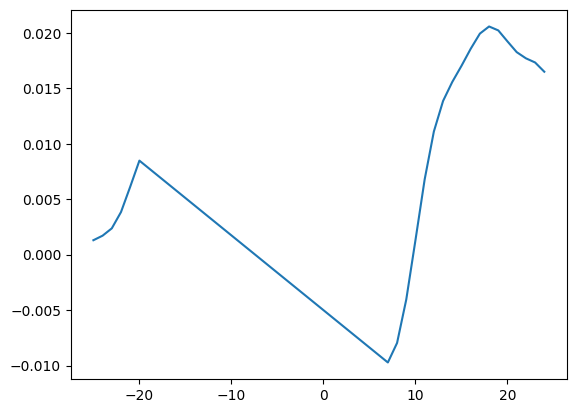

In [ ]:

plt.plot(lags[mask], res[225][score_type].mean(-1)[mask] - res[224][score_type].mean(-1)[mask])

In [54]:
t = 229
com = np.sum(lags[:t_0_idx] * res[t][score_type][:t_0_idx].mean(-1)) / np.sum(res[t][score_type][:t_0_idx].mean(-1))

# Find the index corresponding to the center of mass
com_index = np.argmin(np.abs(lags[:t_0_idx] - com))

print("The index corresponding to the center of mass is:", com_index)

The index corresponding to the center of mass is: 15


In [59]:
lags[:t_0_idx]

array([-25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13,
       -12, -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1])

In [56]:
com

-9.844138965813888

In [31]:
baseline_idx = np.where(np.array(list(res.keys())) < 200)[0]

In [37]:
np.array(list(keys))[baseline_idx]

array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151,
       152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164,
       165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177,
       178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190,
       191, 192, 193, 194, 195, 196, 197, 198, 199])

In [32]:
baseline_idx

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [42]:
len(baseline_idx)

100

In [43]:
keys = res.keys()
baseline_mean = np.array([res[t][score_type].mean(-1) for t in np.array(list(keys))[baseline_idx]]).mean(0)
baseline_mean.shape

(50,)

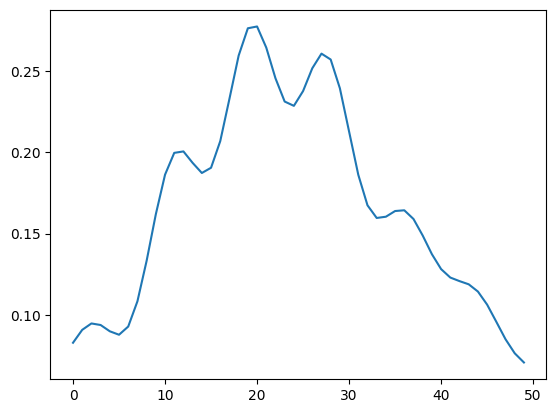

In [44]:
plt.plot(baseline_mean)

/tmp/ipykernel_1152679/3110112920.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis", len(keys))
/tmp/ipykernel_1152679/3110112920.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


Text(0.5, 1.0, 'MOp to left elbow. All trials. 300ms windows')

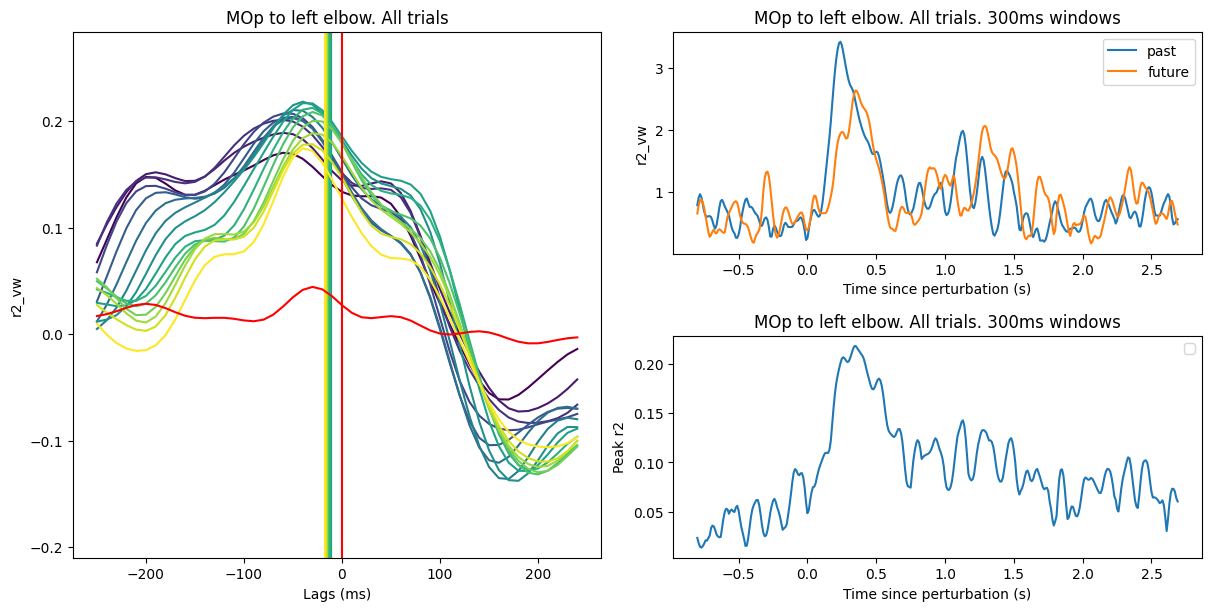

In [286]:
time_bins = np.arange(100, 450, step=1)
lags = np.arange(-25, 25, step=1)
window = 20
time_secs = (time_bins / 100) - 1.8
t_0_idx = np.where(lags == 0)[0][0]
score_type = 'r2_vw'


res = res_['VAL']

baseline_idx = np.where(np.array(list(res.keys())) < 200)[0]
baseline_mean = np.array([res[t][score_type].mean(-1) for t in np.array(list(res.keys()))[baseline_idx]]).mean(0)



fig = plt.figure(figsize=(12, 6), constrained_layout=True)
gs = mpl.gridspec.GridSpec(nrows=2, ncols=2, figure=fig, width_ratios=[1, 1.0], height_ratios=[1, 1])

ax_left = fig.add_subplot(gs[:, 0])   # spans both rows on the left
ax_rt   = fig.add_subplot(gs[0, 1])   # top-right
ax_rb   = fig.add_subplot(gs[1, 1])   # bottom-right

# keys = list(res.keys())[75:77] + list(res.keys())[100:102]
keys = np.arange(200, 230, step=2)
cmap = mpl.cm.get_cmap("viridis", len(keys))
colors = [cmap(i) for i in range(len(keys))]
# curves_masked = np.maximum(curves, 0)
test_coms = []
for i, t in enumerate(keys):
    vizutils.shaded_errorbar(ax_left, lags*10, res[t][score_type], label=f'{np.round((t / 100) -2, 2)}s -> {np.round(((t+window) / 100) - 2, 2)}s', 
                            errorStat=scipy.stats.sem, alpha_err=0.0,
                            color=colors[i],
                            )
    com = compute_com(lags, res[t][score_type].mean(-1))
    test_coms.append(com)
    ax_left.axvline(com, color=colors[i])
test_coms = np.array(test_coms)
ax_left.plot(lags*10, baseline_mean, color='r')
ax_left.axvline(0, color='r')

ax_left.set_xlabel('Lags (ms)')
ax_left.set_title('MOp to left elbow. All trials')
ax_left.set_ylabel(f'{score_type}')
# ax_left.legend()
# ax_left.set_ylim(0, 0.5)
# ax_left.set_xlim(-250, 250)



past, future = [], []
for t in res.keys():
    # past.append(np.trapz(res[t][score_type].mean(-1)[:t_0_idx]))
    # future.append(np.trapz(res[t][score_type].mean(-1)[t_0_idx:]))
    past.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[:t_0_idx], baseline_mean[:t_0_idx]))
    future.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[t_0_idx:], baseline_mean[t_0_idx:]))

ax_rt.errorbar(time_secs, past, fmt='-', label='past')
ax_rt.errorbar(time_secs, future, fmt='-', label='future')
ax_rt.set_ylabel(score_type)
ax_rt.set_xlabel('Time since perturbation (s)')
ax_rt.legend()
ax_rt.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rt.set_xlim(-0.75, 1.25)
# ax_rt.set_ylim(0, 4.2)

peak_r2 = []
auc = []
for t in res.keys():
    # 
    auc.append(np.trapz(res[t][score_type].mean(-1)))
    peak_r2.append(np.max(res[t][score_type].mean(-1)))

ax_rb.plot(time_secs, peak_r2)
# ax_rb.plot(time_secs, com_future)

ax_rb.set_ylabel('Peak r2')
ax_rb.set_xlabel('Time since perturbation (s)')
ax_rb.legend()
ax_rb.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rb.set_xlim(-0.01, 0.75)
# ax_rb.set_ylim(-50, 50)



    

/tmp/ipykernel_1152679/778820241.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis", len(keys))
/tmp/ipykernel_1152679/778820241.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


Text(0.5, 1.0, 'MOp to left elbow. All trials. 300ms windows')

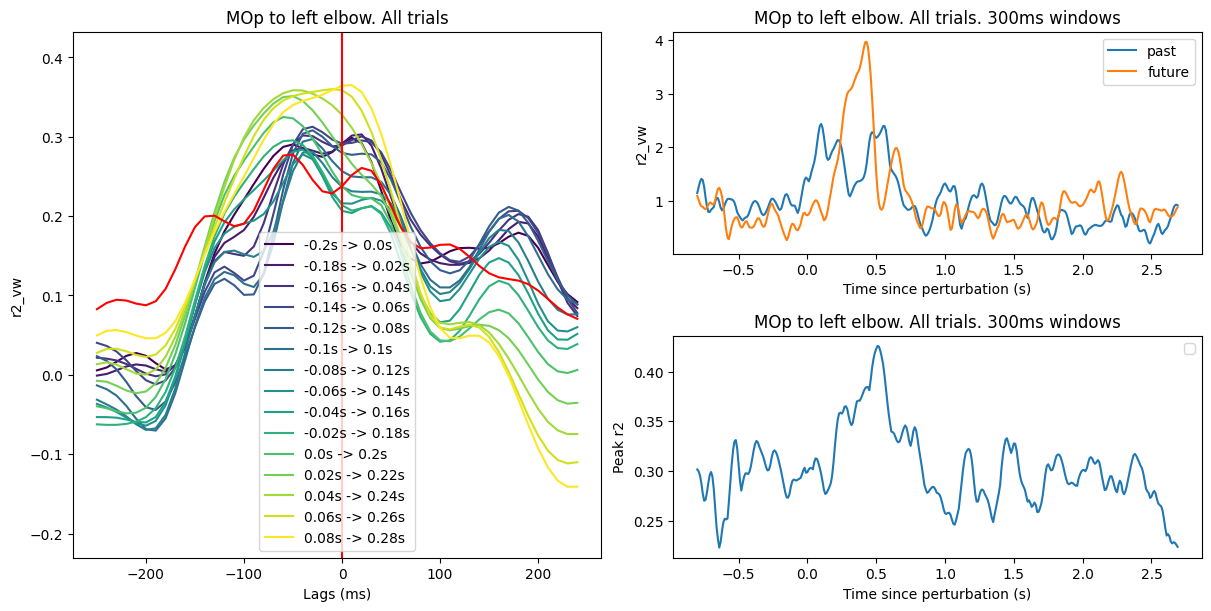

In [285]:
time_bins = np.arange(100, 450, step=1)
lags = np.arange(-25, 25, step=1)
window = 20
time_secs = (time_bins / 100) - 1.8
t_0_idx = np.where(lags == 0)[0][0]
score_type = 'r2_vw'


res = res_['MOp']

baseline_idx = np.where(np.array(list(res.keys())) < 200)[0]
baseline_mean = np.array([res[t][score_type].mean(-1) for t in np.array(list(res.keys()))[baseline_idx]]).mean(0)



fig = plt.figure(figsize=(12, 6), constrained_layout=True)
gs = mpl.gridspec.GridSpec(nrows=2, ncols=2, figure=fig, width_ratios=[1, 1.0], height_ratios=[1, 1])

ax_left = fig.add_subplot(gs[:, 0])   # spans both rows on the left
ax_rt   = fig.add_subplot(gs[0, 1])   # top-right
ax_rb   = fig.add_subplot(gs[1, 1])   # bottom-right

# keys = list(res.keys())[75:77] + list(res.keys())[100:102]
keys = np.arange(180, 210, step=2)
cmap = mpl.cm.get_cmap("viridis", len(keys))
colors = [cmap(i) for i in range(len(keys))]
# curves_masked = np.maximum(curves, 0)
test_coms = []
for i, t in enumerate(keys):
    vizutils.shaded_errorbar(ax_left, lags*10, res[t][score_type], label=f'{np.round((t / 100) -2, 2)}s -> {np.round(((t+window) / 100) - 2, 2)}s', 
                            errorStat=scipy.stats.sem, alpha_err=0.0,
                            color=colors[i],
                            )
    com = compute_com(lags, res[t][score_type].mean(-1))
    test_coms.append(com)
    # ax_left.axvline(com, color=colors[i])
test_coms = np.array(test_coms)
ax_left.plot(lags*10, baseline_mean, color='r')
ax_left.axvline(0, color='r')

ax_left.set_xlabel('Lags (ms)')
ax_left.set_title('MOp to left elbow. All trials')
ax_left.set_ylabel(f'{score_type}')
ax_left.legend()
# ax_left.set_ylim(0, 0.5)
# ax_left.set_xlim(-250, 250)



past, future = [], []
for t in res.keys():
    # past.append(np.trapz(res[t][score_type].mean(-1)[:t_0_idx] - baseline_mean[:t_0_idx]))
    # future.append(np.trapz(res[t][score_type].mean(-1)[t_0_idx:] - baseline_mean[t_0_idx:]))
    past.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[:t_0_idx], baseline_mean[:t_0_idx]))
    future.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[t_0_idx:], baseline_mean[t_0_idx:]))

ax_rt.errorbar(time_secs, past, fmt='-', label='past')
ax_rt.errorbar(time_secs, future, fmt='-', label='future')
ax_rt.set_ylabel(score_type)
ax_rt.set_xlabel('Time since perturbation (s)')
ax_rt.legend()
ax_rt.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rt.set_xlim(-0.75, 1.25)
# ax_rt.set_ylim(0, 4.2)

peak_r2 = []
auc = []
for t in res.keys():
    # 
    auc.append(np.trapz(res[t][score_type].mean(-1)))
    peak_r2.append(np.max(res[t][score_type].mean(-1)))

ax_rb.plot(time_secs, peak_r2)
# ax_rb.plot(time_secs, com_future)

ax_rb.set_ylabel('Peak r2')
ax_rb.set_xlabel('Time since perturbation (s)')
ax_rb.legend()
ax_rb.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rb.set_xlim(-0.01, 0.75)
# ax_rb.set_ylim(-50, 50)



    

/tmp/ipykernel_1152679/4225917846.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis", len(keys))
/tmp/ipykernel_1152679/4225917846.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


Text(0.5, 0, 'past - future')

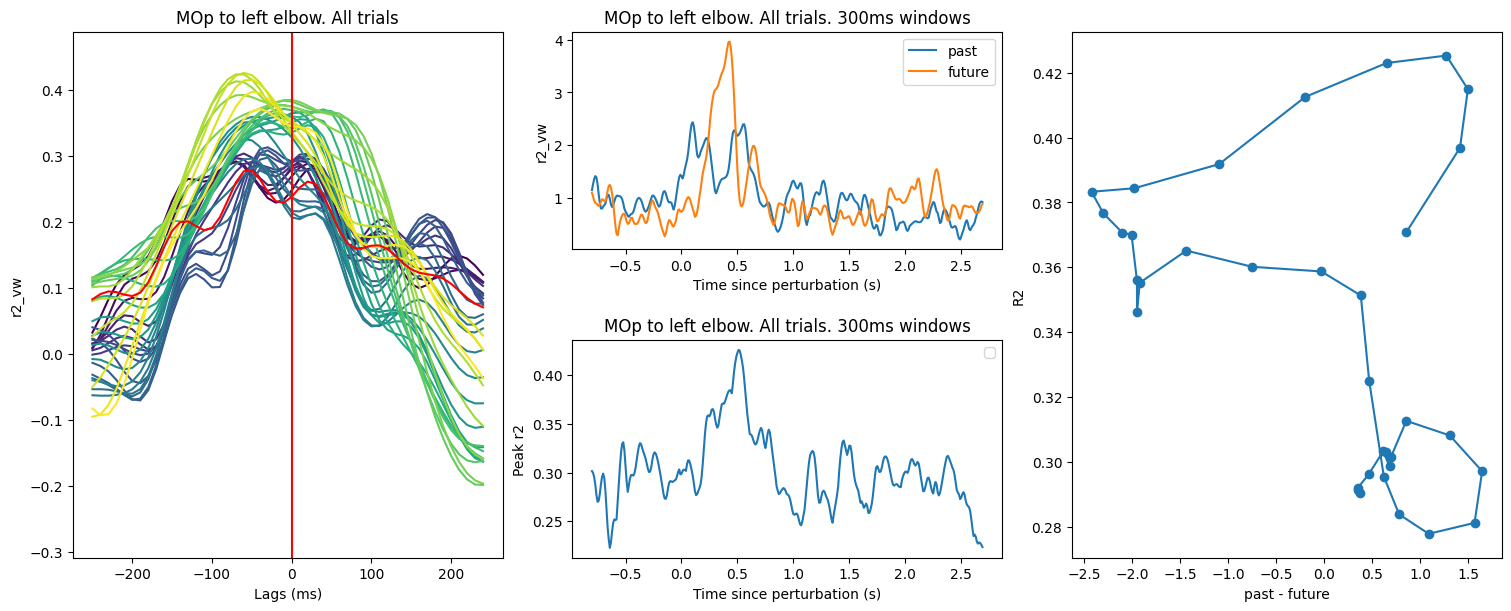

In [335]:
time_bins = np.arange(100, 450, step=1)
lags = np.arange(-25, 25, step=1)
window = 20
time_secs = (time_bins / 100) - 1.8
t_0_idx = np.where(lags == 0)[0][0]
score_type = 'r2_vw'


res = res_['MOp']

baseline_idx = np.where(np.array(list(res.keys())) < 200)[0]
baseline_mean = np.array([res[t][score_type].mean(-1) for t in np.array(list(res.keys()))[baseline_idx]]).mean(0)



fig = plt.figure(figsize=(15, 6), constrained_layout=True)
gs = mpl.gridspec.GridSpec(nrows=2, ncols=3, figure=fig, width_ratios=[1, 1, 1], height_ratios=[1, 1])

ax_left = fig.add_subplot(gs[:, 0])   # spans both rows on the left
ax_rt   = fig.add_subplot(gs[0, 1])   # top-right
ax_rb   = fig.add_subplot(gs[1, 1])   # bottom-right
ax_right   = fig.add_subplot(gs[:, 2])   # bottom-right


# keys = list(res.keys())[75:77] + list(res.keys())[100:102]
keys = np.arange(170, 240, step=2)
cmap = mpl.cm.get_cmap("viridis", len(keys))
colors = [cmap(i) for i in range(len(keys))]
# curves_masked = np.maximum(curves, 0)
test_coms = []
for i, t in enumerate(keys):
    vizutils.shaded_errorbar(ax_left, lags*10, res[t][score_type], label=f'{np.round((t / 100) -2, 2)}s -> {np.round(((t+window) / 100) - 2, 2)}s', 
                            errorStat=scipy.stats.sem, alpha_err=0.0,
                            color=colors[i],
                            )
    com = compute_com(lags, res[t][score_type].mean(-1))
    test_coms.append(com)
    # ax_left.axvline(com, color=colors[i])
test_coms = np.array(test_coms)
ax_left.plot(lags*10, baseline_mean, color='r')
ax_left.axvline(0, color='r')

ax_left.set_xlabel('Lags (ms)')
ax_left.set_title('MOp to left elbow. All trials')
ax_left.set_ylabel(f'{score_type}')
# ax_left.legend()
# ax_left.set_ylim(0, 0.5)
# ax_left.set_xlim(-250, 250)



past, future = [], []
for t in res.keys():
    # past.append(np.trapz(res[t][score_type].mean(-1)[:t_0_idx] - baseline_mean[:t_0_idx]))
    # future.append(np.trapz(res[t][score_type].mean(-1)[t_0_idx:] - baseline_mean[t_0_idx:]))
    past.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[:t_0_idx], baseline_mean[:t_0_idx]))
    future.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[t_0_idx:], baseline_mean[t_0_idx:]))

past, future = np.array(past), np.array(future)

ax_rt.errorbar(time_secs, past, fmt='-', label='past')
ax_rt.errorbar(time_secs, future, fmt='-', label='future')
ax_rt.set_ylabel(score_type)
ax_rt.set_xlabel('Time since perturbation (s)')
ax_rt.legend()
ax_rt.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rt.set_xlim(-0.75, 1.25)
# ax_rt.set_ylim(0, 4.2)

peak_r2 = []
auc = []
for t in res.keys():
    # 
    auc.append(np.trapz(res[t][score_type].mean(-1)))
    peak_r2.append(np.max(res[t][score_type].mean(-1)))

peak_r2 = np.array(peak_r2)
ax_rb.plot(time_secs, peak_r2)
# ax_rb.plot(time_secs, com_future)

ax_rb.set_ylabel('Peak r2')
ax_rb.set_xlabel('Time since perturbation (s)')
ax_rb.legend()
ax_rb.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rb.set_xlim(-0.01, 0.75)
# ax_rb.set_ylim(-50, 50)

# perturbation_idx = np.where((time_secs > 0) & (time_secs < 0.75))[0]
perturbation_idx = np.where(np.isin(time_bins, keys))[0]
diff = past - future
ax_right.errorbar(diff[perturbation_idx], peak_r2[perturbation_idx], fmt='o-')
ax_right.set_ylabel('R2')
ax_right.set_xlabel('past - future')
# ax_right.set_xlim(-1.5, 1.5)
    

/tmp/ipykernel_1152679/3301433221.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis", len(keys))
/tmp/ipykernel_1152679/3301433221.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


(-1.5, 1.5)

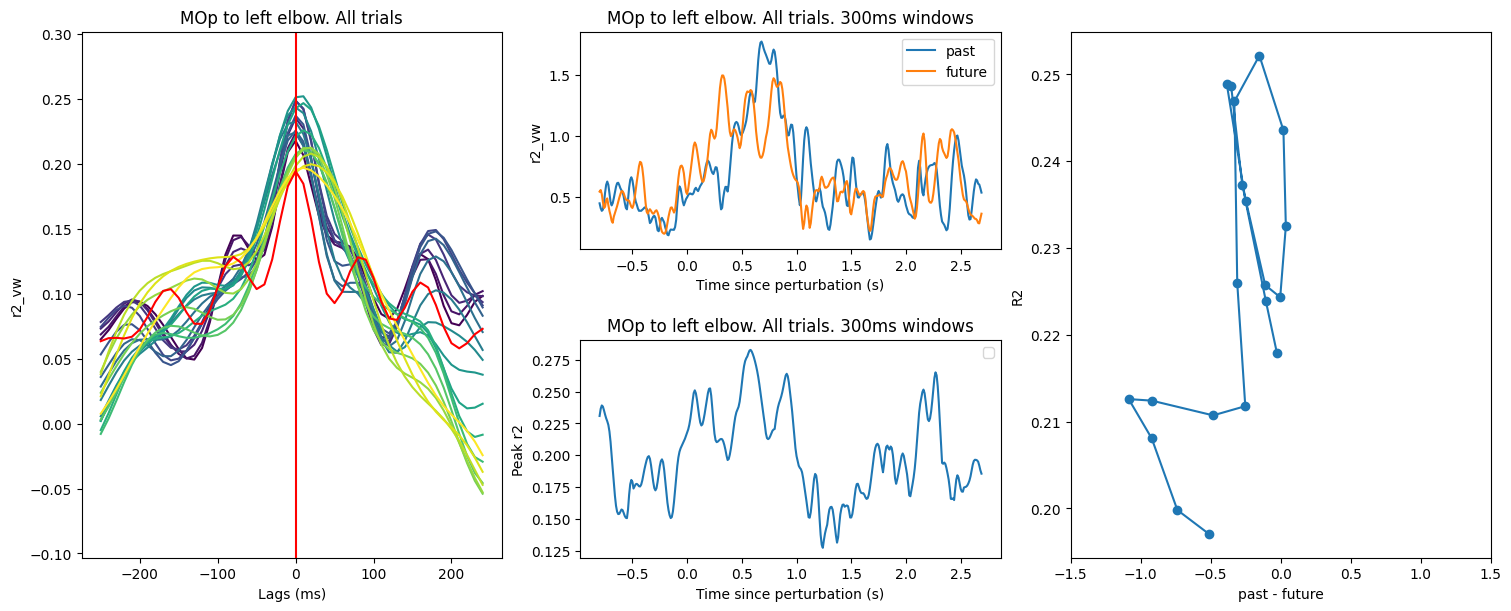

In [331]:
time_bins = np.arange(100, 450, step=1)
lags = np.arange(-25, 25, step=1)
window = 20
time_secs = (time_bins / 100) - 1.8
t_0_idx = np.where(lags == 0)[0][0]
score_type = 'r2_vw'


res = res_['SSp']

baseline_idx = np.where(np.array(list(res.keys())) < 200)[0]
baseline_mean = np.array([res[t][score_type].mean(-1) for t in np.array(list(res.keys()))[baseline_idx]]).mean(0)



fig = plt.figure(figsize=(15, 6), constrained_layout=True)
gs = mpl.gridspec.GridSpec(nrows=2, ncols=3, figure=fig, width_ratios=[1, 1, 1], height_ratios=[1, 1])

ax_left = fig.add_subplot(gs[:, 0])   # spans both rows on the left
ax_rt   = fig.add_subplot(gs[0, 1])   # top-right
ax_rb   = fig.add_subplot(gs[1, 1])   # bottom-right
ax_right   = fig.add_subplot(gs[:, 2])   # bottom-right


# keys = list(res.keys())[75:77] + list(res.keys())[100:102]
keys = np.arange(180, 220, step=2)
cmap = mpl.cm.get_cmap("viridis", len(keys))
colors = [cmap(i) for i in range(len(keys))]
# curves_masked = np.maximum(curves, 0)
test_coms = []
for i, t in enumerate(keys):
    vizutils.shaded_errorbar(ax_left, lags*10, res[t][score_type], label=f'{np.round((t / 100) -2, 2)}s -> {np.round(((t+window) / 100) - 2, 2)}s', 
                            errorStat=scipy.stats.sem, alpha_err=0.0,
                            color=colors[i],
                            )
    com = compute_com(lags, res[t][score_type].mean(-1))
    test_coms.append(com)
    # ax_left.axvline(com, color=colors[i])
test_coms = np.array(test_coms)
ax_left.plot(lags*10, baseline_mean, color='r')
ax_left.axvline(0, color='r')

ax_left.set_xlabel('Lags (ms)')
ax_left.set_title('MOp to left elbow. All trials')
ax_left.set_ylabel(f'{score_type}')
# ax_left.legend()
# ax_left.set_ylim(0, 0.5)
# ax_left.set_xlim(-250, 250)



past, future = [], []
for t in res.keys():
    # past.append(np.trapz(res[t][score_type].mean(-1)[:t_0_idx] - baseline_mean[:t_0_idx]))
    # future.append(np.trapz(res[t][score_type].mean(-1)[t_0_idx:] - baseline_mean[t_0_idx:]))
    past.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[:t_0_idx], baseline_mean[:t_0_idx]))
    future.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[t_0_idx:], baseline_mean[t_0_idx:]))

past, future = np.array(past), np.array(future)

ax_rt.errorbar(time_secs, past, fmt='-', label='past')
ax_rt.errorbar(time_secs, future, fmt='-', label='future')
ax_rt.set_ylabel(score_type)
ax_rt.set_xlabel('Time since perturbation (s)')
ax_rt.legend()
ax_rt.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rt.set_xlim(-0.75, 1.25)
# ax_rt.set_ylim(0, 4.2)

peak_r2 = []
auc = []
for t in res.keys():
    # 
    auc.append(np.trapz(res[t][score_type].mean(-1)))
    peak_r2.append(np.max(res[t][score_type].mean(-1)))

peak_r2 = np.array(peak_r2)
ax_rb.plot(time_secs, peak_r2)
# ax_rb.plot(time_secs, com_future)

ax_rb.set_ylabel('Peak r2')
ax_rb.set_xlabel('Time since perturbation (s)')
ax_rb.legend()
ax_rb.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rb.set_xlim(-0.01, 0.75)
# ax_rb.set_ylim(-50, 50)

# perturbation_idx = np.where((time_secs > 0) & (time_secs < 0.75))[0]
perturbation_idx = np.where(np.isin(time_bins, keys))[0]
diff = past - future
ax_right.errorbar(diff[perturbation_idx], peak_r2[perturbation_idx], fmt='o-')
ax_right.set_ylabel('R2')
ax_right.set_xlabel('past - future')
ax_right.set_xlim(-1.5, 1.5)
    

/tmp/ipykernel_1152679/4051901080.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis", len(keys))
/tmp/ipykernel_1152679/4051901080.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


(-1.5, 1.5)

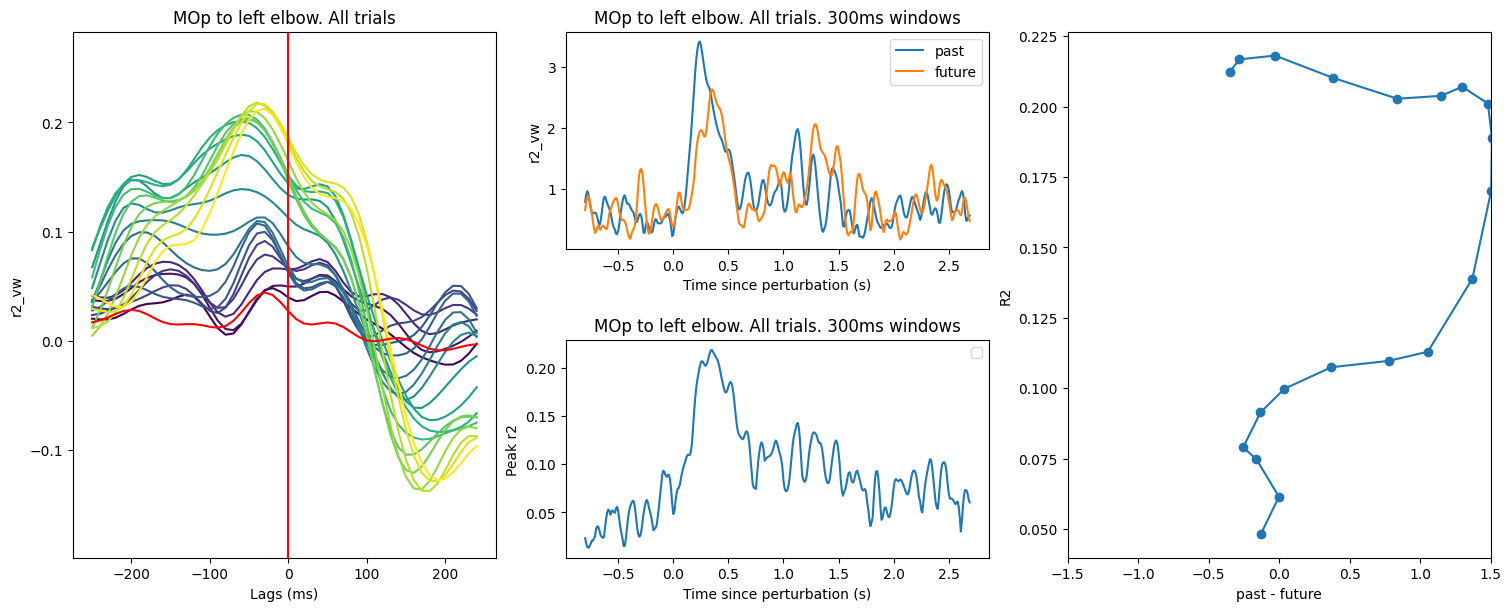

In [332]:
time_bins = np.arange(100, 450, step=1)
lags = np.arange(-25, 25, step=1)
window = 20
time_secs = (time_bins / 100) - 1.8
t_0_idx = np.where(lags == 0)[0][0]
score_type = 'r2_vw'


res = res_['VAL']

baseline_idx = np.where(np.array(list(res.keys())) < 200)[0]
baseline_mean = np.array([res[t][score_type].mean(-1) for t in np.array(list(res.keys()))[baseline_idx]]).mean(0)



fig = plt.figure(figsize=(15, 6), constrained_layout=True)
gs = mpl.gridspec.GridSpec(nrows=2, ncols=3, figure=fig, width_ratios=[1, 1, 1], height_ratios=[1, 1])

ax_left = fig.add_subplot(gs[:, 0])   # spans both rows on the left
ax_rt   = fig.add_subplot(gs[0, 1])   # top-right
ax_rb   = fig.add_subplot(gs[1, 1])   # bottom-right
ax_right   = fig.add_subplot(gs[:, 2])   # bottom-right


# keys = list(res.keys())[75:77] + list(res.keys())[100:102]
keys = np.arange(180, 220, step=2)
cmap = mpl.cm.get_cmap("viridis", len(keys))
colors = [cmap(i) for i in range(len(keys))]
# curves_masked = np.maximum(curves, 0)
test_coms = []
for i, t in enumerate(keys):
    vizutils.shaded_errorbar(ax_left, lags*10, res[t][score_type], label=f'{np.round((t / 100) -2, 2)}s -> {np.round(((t+window) / 100) - 2, 2)}s', 
                            errorStat=scipy.stats.sem, alpha_err=0.0,
                            color=colors[i],
                            )
    com = compute_com(lags, res[t][score_type].mean(-1))
    test_coms.append(com)
    # ax_left.axvline(com, color=colors[i])
test_coms = np.array(test_coms)
ax_left.plot(lags*10, baseline_mean, color='r')
ax_left.axvline(0, color='r')

ax_left.set_xlabel('Lags (ms)')
ax_left.set_title('MOp to left elbow. All trials')
ax_left.set_ylabel(f'{score_type}')
# ax_left.legend()
# ax_left.set_ylim(0, 0.5)
# ax_left.set_xlim(-250, 250)



past, future = [], []
for t in res.keys():
    # past.append(np.trapz(res[t][score_type].mean(-1)[:t_0_idx] - baseline_mean[:t_0_idx]))
    # future.append(np.trapz(res[t][score_type].mean(-1)[t_0_idx:] - baseline_mean[t_0_idx:]))
    past.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[:t_0_idx], baseline_mean[:t_0_idx]))
    future.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[t_0_idx:], baseline_mean[t_0_idx:]))

past, future = np.array(past), np.array(future)

ax_rt.errorbar(time_secs, past, fmt='-', label='past')
ax_rt.errorbar(time_secs, future, fmt='-', label='future')
ax_rt.set_ylabel(score_type)
ax_rt.set_xlabel('Time since perturbation (s)')
ax_rt.legend()
ax_rt.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rt.set_xlim(-0.75, 1.25)
# ax_rt.set_ylim(0, 4.2)

peak_r2 = []
auc = []
for t in res.keys():
    # 
    auc.append(np.trapz(res[t][score_type].mean(-1)))
    peak_r2.append(np.max(res[t][score_type].mean(-1)))

peak_r2 = np.array(peak_r2)
ax_rb.plot(time_secs, peak_r2)
# ax_rb.plot(time_secs, com_future)

ax_rb.set_ylabel('Peak r2')
ax_rb.set_xlabel('Time since perturbation (s)')
ax_rb.legend()
ax_rb.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rb.set_xlim(-0.01, 0.75)
# ax_rb.set_ylim(-50, 50)

# perturbation_idx = np.where((time_secs > 0) & (time_secs < 0.75))[0]
perturbation_idx = np.where(np.isin(time_bins, keys))[0]
diff = past - future
ax_right.errorbar(diff[perturbation_idx], peak_r2[perturbation_idx], fmt='o-')
ax_right.set_ylabel('R2')
ax_right.set_xlabel('past - future')
ax_right.set_xlim(-1.5, 1.5)
    

/tmp/ipykernel_1152679/2306619350.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis", len(keys))
/tmp/ipykernel_1152679/2306619350.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


(-1.5, 1.5)

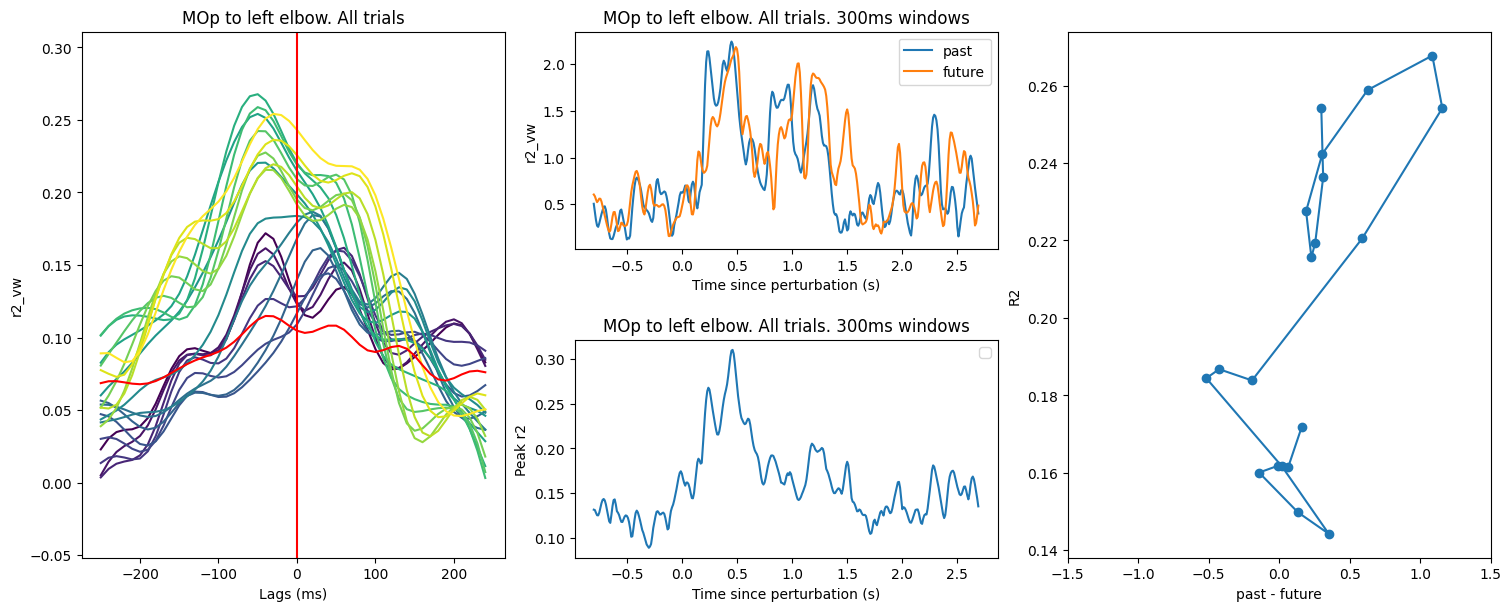

In [330]:
time_bins = np.arange(100, 450, step=1)
lags = np.arange(-25, 25, step=1)
window = 20
time_secs = (time_bins / 100) - 1.8
t_0_idx = np.where(lags == 0)[0][0]
score_type = 'r2_vw'


res = res_['CP']

baseline_idx = np.where(np.array(list(res.keys())) < 200)[0]
baseline_mean = np.array([res[t][score_type].mean(-1) for t in np.array(list(res.keys()))[baseline_idx]]).mean(0)



fig = plt.figure(figsize=(15, 6), constrained_layout=True)
gs = mpl.gridspec.GridSpec(nrows=2, ncols=3, figure=fig, width_ratios=[1, 1, 1], height_ratios=[1, 1])

ax_left = fig.add_subplot(gs[:, 0])   # spans both rows on the left
ax_rt   = fig.add_subplot(gs[0, 1])   # top-right
ax_rb   = fig.add_subplot(gs[1, 1])   # bottom-right
ax_right   = fig.add_subplot(gs[:, 2])   # bottom-right


# keys = list(res.keys())[75:77] + list(res.keys())[100:102]
keys = np.arange(180, 220, step=2)
cmap = mpl.cm.get_cmap("viridis", len(keys))
colors = [cmap(i) for i in range(len(keys))]
# curves_masked = np.maximum(curves, 0)
test_coms = []
for i, t in enumerate(keys):
    vizutils.shaded_errorbar(ax_left, lags*10, res[t][score_type], label=f'{np.round((t / 100) -2, 2)}s -> {np.round(((t+window) / 100) - 2, 2)}s', 
                            errorStat=scipy.stats.sem, alpha_err=0.0,
                            color=colors[i],
                            )
    com = compute_com(lags, res[t][score_type].mean(-1))
    test_coms.append(com)
    # ax_left.axvline(com, color=colors[i])
test_coms = np.array(test_coms)
ax_left.plot(lags*10, baseline_mean, color='r')
ax_left.axvline(0, color='r')

ax_left.set_xlabel('Lags (ms)')
ax_left.set_title('MOp to left elbow. All trials')
ax_left.set_ylabel(f'{score_type}')
# ax_left.legend()
# ax_left.set_ylim(0, 0.5)
# ax_left.set_xlim(-250, 250)



past, future = [], []
for t in res.keys():
    # past.append(np.trapz(res[t][score_type].mean(-1)[:t_0_idx] - baseline_mean[:t_0_idx]))
    # future.append(np.trapz(res[t][score_type].mean(-1)[t_0_idx:] - baseline_mean[t_0_idx:]))
    past.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[:t_0_idx], baseline_mean[:t_0_idx]))
    future.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[t_0_idx:], baseline_mean[t_0_idx:]))

past, future = np.array(past), np.array(future)

ax_rt.errorbar(time_secs, past, fmt='-', label='past')
ax_rt.errorbar(time_secs, future, fmt='-', label='future')
ax_rt.set_ylabel(score_type)
ax_rt.set_xlabel('Time since perturbation (s)')
ax_rt.legend()
ax_rt.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rt.set_xlim(-0.75, 1.25)
# ax_rt.set_ylim(0, 4.2)

peak_r2 = []
auc = []
for t in res.keys():
    # 
    auc.append(np.trapz(res[t][score_type].mean(-1)))
    peak_r2.append(np.max(res[t][score_type].mean(-1)))

peak_r2 = np.array(peak_r2)
ax_rb.plot(time_secs, peak_r2)
# ax_rb.plot(time_secs, com_future)

ax_rb.set_ylabel('Peak r2')
ax_rb.set_xlabel('Time since perturbation (s)')
ax_rb.legend()
ax_rb.set_title("MOp to left elbow. All trials. 300ms windows")
# ax_rb.set_xlim(-0.01, 0.75)
# ax_rb.set_ylim(-50, 50)

# perturbation_idx = np.where((time_secs > 0) & (time_secs < 0.75))[0]
perturbation_idx = np.where(np.isin(time_bins, keys))[0]
diff = past - future
ax_right.errorbar(diff[perturbation_idx], peak_r2[perturbation_idx], fmt='o-')
ax_right.set_ylabel('R2')
ax_right.set_xlabel('past - future')
ax_right.set_xlim(-1.5, 1.5)
    

# Refactored function

In [395]:
def plot_brain_area_analysis(res_, brain_area='MOp', window=20, score_type='r2_vw', time_bins=None, lags=None):
    # Set up the time_secs based on the provided time_bins
    if time_bins is None:
        time_bins = np.arange(100, 450, step=1)
    time_secs = (time_bins / 100) - 1.8
    
    # Define the keys to sample
    keys = np.arange(170, 240, step=2)
    perturbation_idx = np.where(np.isin(time_bins, keys))[0]

    cmap = mpl.cm.get_cmap("viridis", len(keys))
    colors = [cmap(i) for i in range(len(keys))]
    
    # Extract results for the specified brain area
    res = res_[brain_area]
    
    # Set up the baseline mean using indices where the values are less than 200
    baseline_idx = np.where(np.array(list(res.keys())) < 170)[0]
    baseline_mean = np.array([res[t][score_type].mean(-1) for t in np.array(list(res.keys()))[baseline_idx]]).mean(0)

    # Create figure with subplots
    fig = plt.figure(figsize=(15, 6), constrained_layout=True)
    gs = mpl.gridspec.GridSpec(nrows=2, ncols=3, figure=fig, width_ratios=[1, 1, 1], height_ratios=[1, 1])

    # Subplot assignments
    ax_left = fig.add_subplot(gs[:, 0])   # Spans both rows on the left
    ax_rt   = fig.add_subplot(gs[0, 1])   # Top-right
    ax_rb   = fig.add_subplot(gs[1, 1])   # Bottom-right
    ax_right   = fig.add_subplot(gs[:, 2])   # Right

    # Calculate the center of mass (COM) for each key in the specified range
    for i, t in enumerate(keys):
        vizutils.shaded_errorbar(ax_left, lags*10, res[t][score_type], label=f'{np.round((t / 100) - 2, 2)}s -> {np.round(((t + window) / 100) - 2, 2)}s',
                                 errorStat=scipy.stats.sem, alpha_err=0.0, color=colors[i])

    
    # Plot the baseline mean and the vertical line for the COM
    ax_left.plot(lags*10, baseline_mean, color='r')
    ax_left.axvline(0, color='r')

    ax_left.set_xlabel('Lags (ms)')
    ax_left.set_title(f'{brain_area} to left elbow. All trials')
    ax_left.set_ylabel(f'{score_type}')
    
    # Compute the deviation from baseline for past and future time windows
    past, future = [], []
    t_0_idx = np.where(lags == 0)[0][0]
    for t in res.keys():
        past.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[:t_0_idx], baseline_mean[:t_0_idx]))
        future.append(compute_deviation_from_baseline(res[t][score_type].mean(-1)[t_0_idx:], baseline_mean[t_0_idx:]))
    
    past, future = np.array(past), np.array(future)

    # Plot past and future deviations
    ax_rt.errorbar(time_secs, past, fmt='-', label='past')
    ax_rt.errorbar(time_secs, future, fmt='-', label='future')
    ax_rt.set_ylabel(score_type)
    ax_rt.set_xlabel('Time since perturbation (s)')
    ax_rt.legend()
    ax_rt.set_title(f"{brain_area} to left elbow. All trials. 200ms windows")
    ax_rt.axvline(time_secs[perturbation_idx][0], color='r')
    ax_rt.axvline(time_secs[perturbation_idx][-1], color='r')

    
    # Calculate peak r² and AUC
    peak_r2 = []
    auc = []
    for t in res.keys():
        auc.append(np.trapz(res[t][score_type].mean(-1)))
        peak_r2.append(np.max(res[t][score_type].mean(-1)))
    
    peak_r2 = np.array(peak_r2)
    ax_rb.plot(time_secs, peak_r2)
    ax_rb.axvline(time_secs[perturbation_idx][0], color='r')
    ax_rb.axvline(time_secs[perturbation_idx][-1], color='r')

    
    ax_rb.set_ylabel('Peak r2')
    ax_rb.set_xlabel('Time since perturbation (s)')
    ax_rb.legend()
    ax_rb.set_title(f"{brain_area} to left elbow. All trials. 200ms windows")
    
    # Find indices of perturbation events
    diff = future - past
    
    # Plot the difference in past vs future deviations vs peak r²
    norm_peak_r2 = peak_r2 - peak_r2[baseline_idx].mean()
    
    ax_right.errorbar(diff[perturbation_idx], norm_peak_r2[perturbation_idx], fmt='-', color='grey')
    for idx, color in zip(perturbation_idx, colors):
        ax_right.errorbar(diff[idx], norm_peak_r2[idx], fmt='o-', color=color, markersize=10)

    ax_right.set_ylabel('R2')
    ax_right.set_xlabel('past - future')
    ax_right.set_xlim(-3, 3)
    ax_right.set_ylim(-0.02, 0.2)

    ax_right.axvline(0, color='r')

    plt.show()

/tmp/ipykernel_1152679/3959368040.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis", len(keys))
/tmp/ipykernel_1152679/3959368040.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


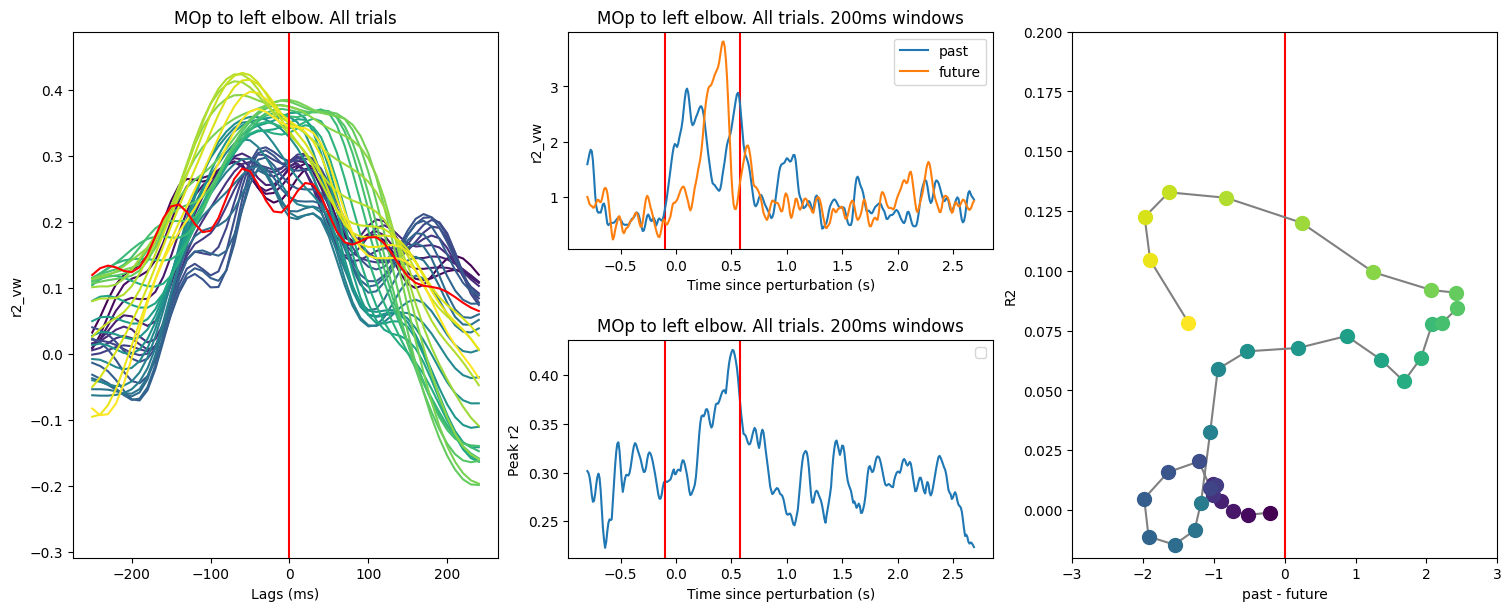

/tmp/ipykernel_1152679/3959368040.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


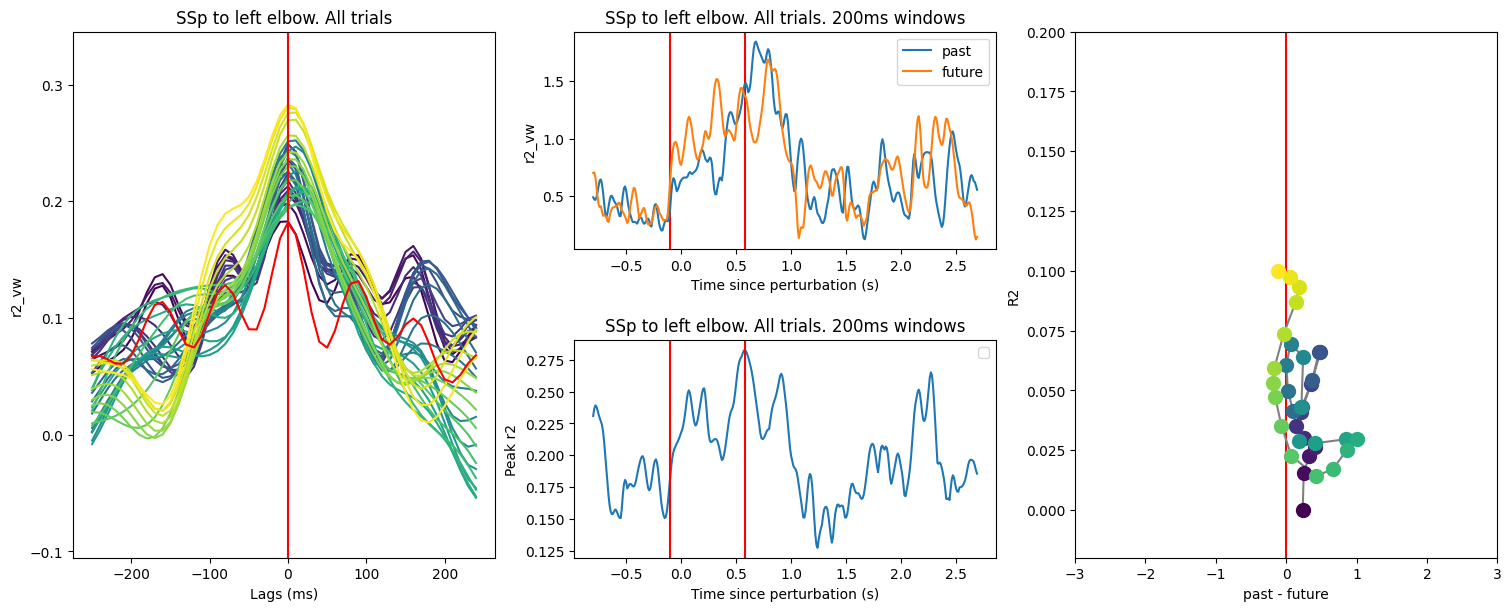

/tmp/ipykernel_1152679/3959368040.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


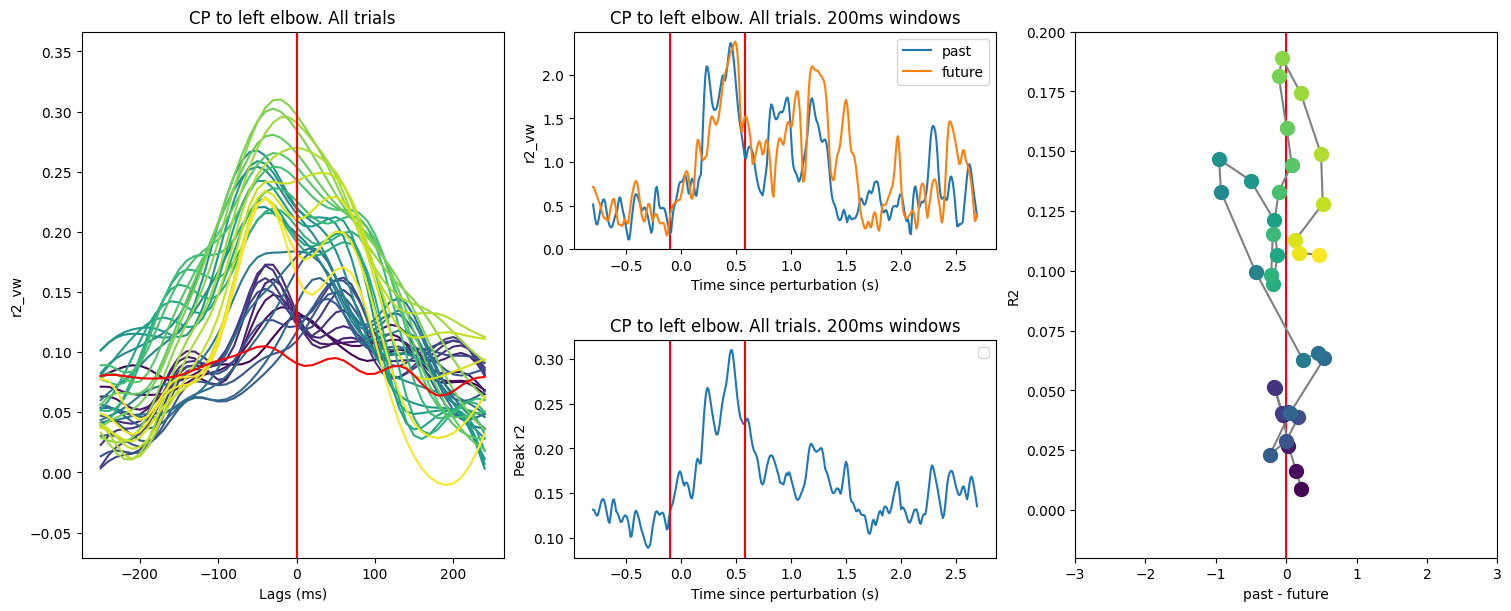

/tmp/ipykernel_1152679/3959368040.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rb.legend()


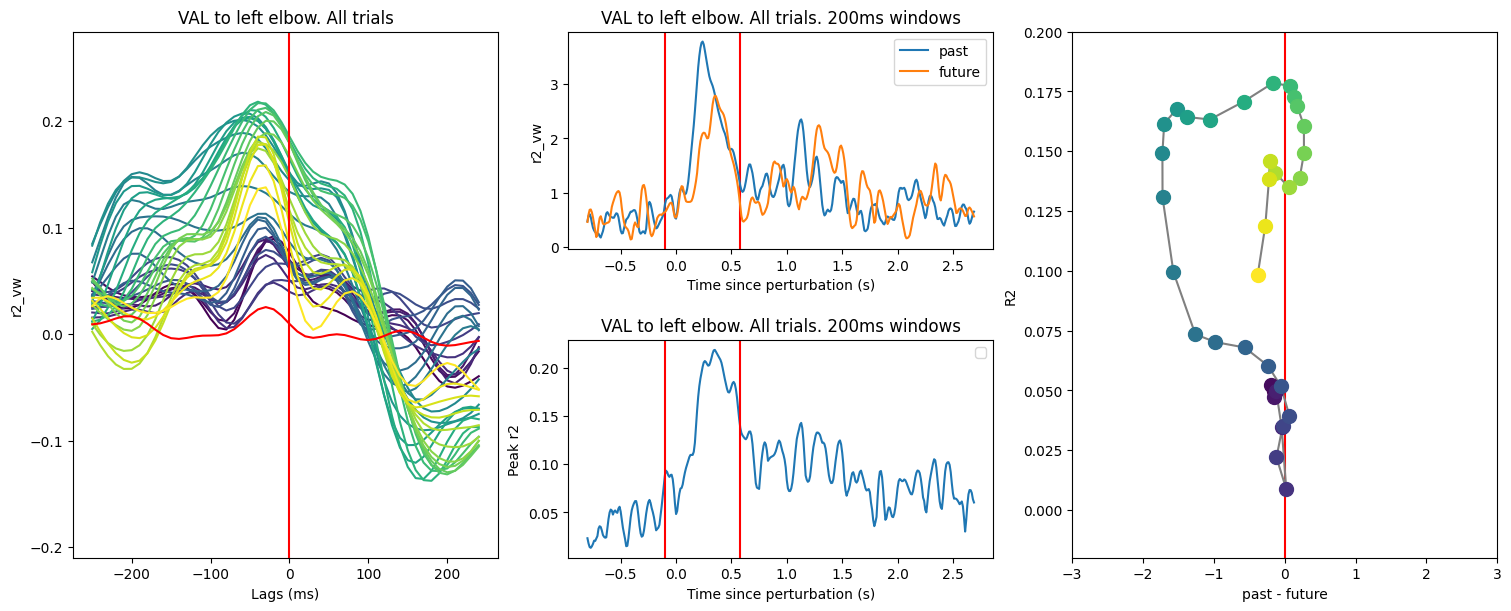

In [396]:
areas = ['MOp', 'SSp', 'CP', 'VAL']
for area in areas:
    plot_brain_area_analysis(res_, brain_area=area, window=20, score_type='r2_vw', 
                            time_bins=np.arange(100, 450, step=1), lags=np.arange(-25, 25, step=1))

## Load all results

In [ ]:
with open("/data/equake_results/lagged_results_all_areas_left_keypoints.pkl", "rb") as f:
    res = pickle.load(f)

In [ ]:
res.keys()